# Deep neural network

### The Architecture:
1. #### Input(1x3): Our streetlight
2. #### Weights_0_1 (3x4): Connects input to 4 hidden neurons
3. #### Layer_1 (1x4): The __Hidden__ layer.
4. #### Weights_1_2 (4x1): Connects hidden neurons to 1 output.

### Forward: dot → relu → dropout → dot.

### Deltas: Calculate end error → dot it backward → relu2deriv filter → dropout filter.

### Updates: Input.T.dot(Delta).
### some terms:-
>Correlation summarization:
> Neural networks seek to find direct and indirect correlation between an input layer and
an output layer, which are determined by the input and output datasets, respectively.

>Local correlation summarization:
> Any given set of weights optimizes to learn how to correlate its input layer with what the output layer says it should be.

>Global correlation summarization:
> What an earlier layer says it should be can be determined by taking what a later layer says it should be and multiplying it by the weights in between them. This way, later layers can tell earlier layers what kind of signal they need, to ultimately find correlation with the output. This cross-communication is called ___backpropagation___ .

![](assets/naming.png)![](assets/naming2.png)

## Regularization:
#### It is a subset of methods used to encourage generalization in learned models, often by increasing the difficulty for a model to learn the fine-grained details of training data.

## Activation Function:
#### An activation function is a function applied to the neurons in a layer during prediction.

### Constraints of Activation function:
1. The must be continuous and infinite in domain.
2. Good activation functions are monotonic, never changing directions.
3. Good activation functions are nonlinear
4. Good activation functions (and their derivatives) should be efficiently computable.

## Standard hidden-layer activation functions:
1. ___sigmoid___ is the bread and butter activation
2. ___tanh___ is better than ___sigmoid___ for hidden layers




Iteration: 0 | Total Error: 1.3981
Iteration: 10 | Total Error: 0.5979
Iteration: 20 | Total Error: 0.2697
Iteration: 30 | Total Error: 0.0601
Iteration: 40 | Total Error: 0.0102
Iteration: 50 | Total Error: 0.0009
Iteration: 60 | Total Error: 0.0001
Iteration: 70 | Total Error: 0.0000
Iteration: 80 | Total Error: 0.0000
Iteration: 90 | Total Error: 0.0000
Iteration: 100 | Total Error: 0.0000
Iteration: 110 | Total Error: 0.0000
Iteration: 120 | Total Error: 0.0000
Iteration: 130 | Total Error: 0.0000
Iteration: 140 | Total Error: 0.0000
Iteration: 150 | Total Error: 0.0000
Iteration: 160 | Total Error: 0.0000
Iteration: 170 | Total Error: 0.0000
Iteration: 180 | Total Error: 0.0000
Iteration: 190 | Total Error: 0.0000
Iteration: 200 | Total Error: 0.0000
Iteration: 210 | Total Error: 0.0000
Iteration: 220 | Total Error: 0.0000
Iteration: 230 | Total Error: 0.0000
Iteration: 240 | Total Error: 0.0000
Iteration: 250 | Total Error: 0.0000
Iteration: 260 | Total Error: 0.0000
Iteration: 2

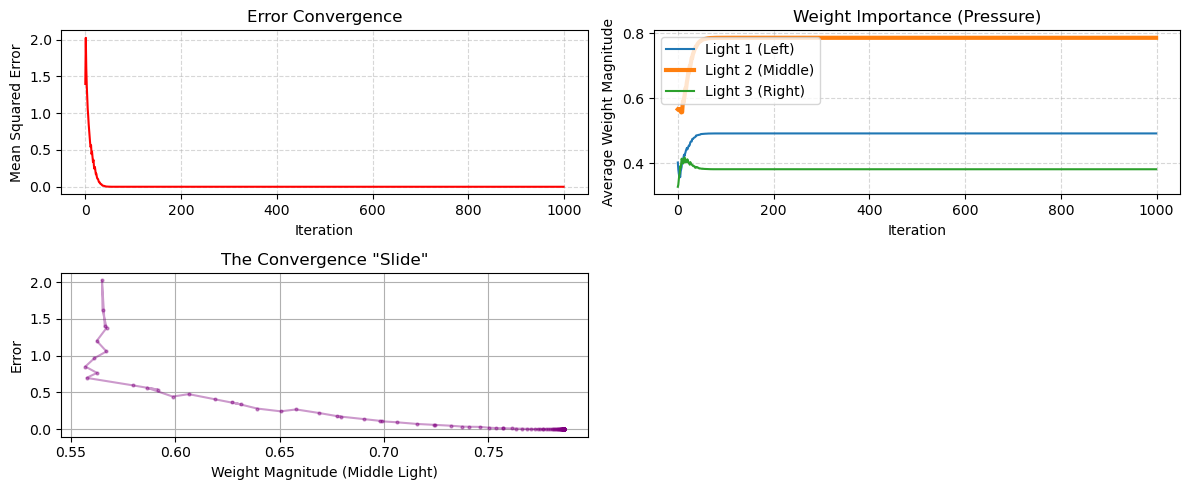

In [24]:
import numpy as np
import matplotlib.pyplot as plt 

# --- ACTIVATION FUNCTIONS ---
# Reason: Provides the 'nonlinear' bend. Without this, the network 
# is just a fancy linear calculator that can't solve XOR.
def relu(x):
    return (x > 0) * x 

# Reason: The 'Blame Filter'. If the neuron didn't fire (was 0), 
# we shouldn't update its weights because it didn't cause the error.
def relu2deriv(output):
    return output > 0

# --- DATASET ---
streetlights = np.array([[1,0,1], [0,1,1], [0,0,1], [1,1,1]])
walk_vs_stop = np.array([[1], [1], [0], [0]]) 

alpha = 0.2
hidden_size = 4 # 4 'Hidden Experts' to look for patterns

# --- WEIGHT INITIALIZATION ---
# Reason: Randomness 'breaks symmetry' so each hidden neuron 
# specializes in a different pattern.
weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1

# --- TRACKING HISTORY FOR PLOTTING ---
error_history = []
weight_history = [] # To store the 'Importance' of each of the 3 lights

for i in range(1000): # Increased iterations slightly for a smoother graph
    layer_2_error = 0
    
    # STOCHASTIC LOOP: Learn from one example at a time
    for j in range(len(streetlights)):
        
        # --- FORWARD PASS ---
        # Data Flow: Input -> Hidden -> Output
        layer_0 = streetlights[j:j+1]                   # Shape: (1, 3)
        
        # Dot product generates the hidden layer signal
        layer_1 = relu(np.dot(layer_0, weights_0_1))    # Shape: (1, 4)
        
        # Dot product generates the final prediction
        layer_2 = np.dot(layer_1, weights_1_2)          # Shape: (1, 1)

        # --- ERROR TRACKING ---
        # Squared error for monitoring. Not used for the update.
        layer_2_error += np.sum((layer_2 - walk_vs_stop[j:j+1]) ** 2)

        # --- BACKWARD PASS ---
        # Step 1: Calculate 'Distance' from truth at the end
        layer_2_delta = (layer_2 - walk_vs_stop[j:j+1]) # Shape: (1, 1)
        
        # Step 2: 'Project' that error back to the hidden layer.
        # layer_2_delta(1,1) . weights_1_2.T(1,4) = (1,4) vector of blame.
        # We then multiply by relu2deriv to 'silence' the blame for 0-nodes.
        layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)

        # --- WEIGHT UPDATES ---
        # Use the 'Weight Delta' formula: Delta * Input
        # weights_1_2: (4, 1) updated by layer_1.T(4, 1) . layer_2_delta(1, 1)
        weights_1_2 -= alpha * layer_1.T.dot(layer_2_delta)
        
        # weights_0_1: (3, 4) updated by layer_0.T(3, 1) . layer_1_delta(1, 4)
        weights_0_1 -= alpha * layer_0.T.dot(layer_1_delta)
        
    # Store history for visualization
    error_history.append(layer_2_error)
    # We take the mean absolute weight connected to each of the 3 input lights
    weight_history.append(np.mean(np.abs(weights_0_1), axis=1))
        
    if i % 10 == 0:
        print(f"Iteration: {i} | Total Error: {layer_2_error:.4f}")

# --- PLOTTING LOGIC ---
plt.figure(figsize=(12, 5))

# Plot 1: Error Rate
plt.subplot(2, 2, 1)
plt.plot(error_history, label='Training Error', color='red')
plt.title('Error Convergence')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.grid(True, linestyle='--', alpha=0.5)

# Plot 2: Weight Importance
plt.subplot(2, 2, 2)
weight_history = np.array(weight_history)
plt.plot(weight_history[:, 0], label='Light 1 (Left)')
plt.plot(weight_history[:, 1], label='Light 2 (Middle)', linewidth=3) # The signal
plt.plot(weight_history[:, 2], label='Light 3 (Right)')
plt.title('Weight Importance (Pressure)')
plt.xlabel('Iteration')
plt.ylabel('Average Weight Magnitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(2,2,3)
plt.plot(weight_history[:, 1], error_history, color='purple', marker='o', markersize=2, alpha=0.4)
plt.title('The Convergence "Slide"')
plt.xlabel('Weight Magnitude (Middle Light)')
plt.ylabel('Error')
plt.grid(True)


plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from keras.datasets import mnist

# 1. LOAD DATA
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. PRE-PROCESS (Flatten and Scale to 0-1)
images = x_train[0:1000].reshape(1000, 28*28) / 255
labels = y_train[0:1000]

# One-hot encoding (Turning '3' into [0,0,0,1...])
one_hot_labels = np.zeros((len(labels), 10))
for i, l in enumerate(labels):
    one_hot_labels[i][l] = 1
labels = one_hot_labels

# 3. ACTIVATIONS
def tanh(x): return np.tanh(x)
def tanh2deriv(output): return 1 - (output ** 2)
def softmax(x):
    temp = np.exp(x)
    return temp / np.sum(temp, axis=1, keepdims=True)

# 4. HYPERPARAMS
alpha, iterations, hidden_size = (2, 300, 100)
pixels_per_image, num_labels = (784, 10)
batch_size = 100

# Weights (Scaled specifically for Tanh)
weights_0_1 = 0.02 * np.random.random((pixels_per_image, hidden_size)) - 0.01
weights_1_2 = 0.2 * np.random.random((hidden_size, num_labels)) - 0.1

# 5. TRAINING LOOP
for j in range(iterations):
    correct_cnt = 0
    for i in range(int(len(images) / batch_size)):
        batch_start, batch_end = (i * batch_size), ((i+1) * batch_size)
        
        # --- FORWARD ---
        l0 = images[batch_start:batch_end]
        l1 = tanh(np.dot(l0, weights_0_1))
        
        # Dropout Mask (Chapter 7 logic)
        mask = np.random.randint(2, size=l1.shape)
        l1 *= mask * 2
        
        l2 = softmax(np.dot(l1, weights_1_2))

        # --- BACKWARD ---
        # The 'Delta' for Softmax is surprisingly simple: (Pred - Goal) / Batch
        l2_delta = (labels[batch_start:batch_end] - l2) / (batch_size * l2.shape[0])
        
        # The 'Echo' through Tanh
        l1_delta = l2_delta.dot(weights_1_2.T) * tanh2deriv(l1)
        l1_delta *= mask # Dropout in Reverse

        # --- UPDATE ---
        weights_1_2 += alpha * l1.T.dot(l2_delta)
        weights_0_1 += alpha * l0.T.dot(l1_delta)

    if j % 10 == 0:
        print(f"I:{j} | Train-Acc: {correct_cnt/float(len(images))}")S